## Install Dependencies

In [3]:
# Install all required packages
!pip install segmentation-models-pytorch --quiet
!pip install albumentations --quiet
!pip install opencv-python-headless --quiet
!pip install scikit-learn --quiet

print("✅ All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.5 MB/s eta 0:00:00
✅ All packages installed successfully!


## Import Libraries

In [4]:
# Standard library
import os
import random
import glob
import warnings
warnings.filterwarnings('ignore')

# Numerical & data
import numpy as np
import pandas as pd
import cv2

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, precision_score,
                              recall_score, f1_score)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast

# Augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Segmentation model
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

print('✅ All imports successful!')
print(f'PyTorch version  : {torch.__version__}')
print(f'SMP version      : {smp.__version__}')

✅ All imports successful!
PyTorch version  : 2.10.0+cu128
SMP version      : 0.5.0


In [7]:
import os

!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation
!unzip -q lgg-mri-segmentation.zip -d /content/
!rm -f lgg-mri-segmentation.zip
print("✓ Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
100% 714M/714M [00:33<00:00, 22.4MB/s]

✓ Dataset ready!


## Dataset Preparation

In [9]:
image_paths = []
mask_paths  = []

# Every mask file ends with '_mask.tif'
# The corresponding image is the same name without '_mask'
for mask_path in sorted(glob.glob(
        os.path.join('./lgg-mri-segmentation/kaggle_3m', '**', '*_mask.tif'), recursive=True)):
    img_path = mask_path.replace('_mask.tif', '.tif')
    if os.path.exists(img_path):
        image_paths.append(img_path)
        mask_paths.append(mask_path)

print(f'Total image-mask pairs found : {len(image_paths)}')
print()
print('Example pair:')
print(f'  Image : {image_paths[0]}')
print(f'  Mask  : {mask_paths[0]}')

Total image-mask pairs found : 3929

Example pair:
  Image : ./lgg-mri-segmentation/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_10.tif
  Mask  : ./lgg-mri-segmentation/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_10_mask.tif


## Class Balance Analysis

Images WITH  tumour mask : 1373  (34.9%)
Images WITHOUT tumour   : 2556  (65.1%)
Total                   : 3929

Note: Class imbalance is expected in medical datasets.
We will address this with combined BCE + Dice loss in the training cell.


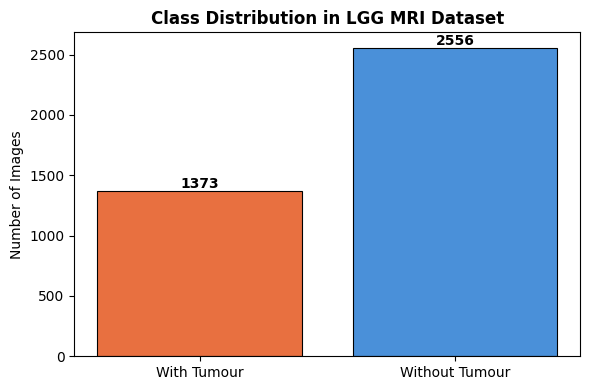

In [10]:
positive = 0   # images WITH tumour
negative = 0   # images WITHOUT tumour (empty mask)

for mp in mask_paths:
    m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    if m is not None and m.max() > 0:
        positive += 1
    else:
        negative += 1

total = len(mask_paths)
print(f'Images WITH  tumour mask : {positive}  ({positive/total*100:.1f}%)')
print(f'Images WITHOUT tumour   : {negative}  ({negative/total*100:.1f}%)')
print(f'Total                   : {total}')
print()
print('Note: Class imbalance is expected in medical datasets.')
print('We will address this with combined BCE + Dice loss in the training cell.')

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['With Tumour', 'Without Tumour'], [positive, negative],
       color=['#E87040', '#4A90D9'], edgecolor='black', linewidth=0.8)
ax.set_title('Class Distribution in LGG MRI Dataset', fontweight='bold')
ax.set_ylabel('Number of Images')
for i, v in enumerate([positive, negative]):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('fig0_class_distribution.png', dpi=120)
plt.show()

## Train / Validation / Test Split

In [11]:
idx = list(range(len(image_paths)))

# First split: 70% train, 30% temp
train_idx, temp_idx = train_test_split(idx, test_size=0.30,
                                        random_state=SEED, shuffle=True)
# Second split: temp → 15% val, 15% test
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.50,
                                        random_state=SEED, shuffle=True)

print(f'Train set  : {len(train_idx)} images  ({len(train_idx)/len(idx)*100:.1f}%)')
print(f'Val   set  : {len(val_idx)}  images  ({len(val_idx)/len(idx)*100:.1f}%)')
print(f'Test  set  : {len(test_idx)} images  ({len(test_idx)/len(idx)*100:.1f}%)')
print(f'Total      : {len(idx)}')

Train set  : 2750 images  (70.0%)
Val   set  : 589  images  (15.0%)
Test  set  : 590 images  (15.0%)
Total      : 3929


## Data Augmentation

In [12]:
# ImageNet mean and std — matches our pretrained ResNet34 encoder
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# ── Training transforms (augmentation) ───────────────────────────────────
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05,
                       scale_limit=0.1,
                       rotate_limit=15, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                               contrast_limit=0.2, p=0.4),
    A.GaussNoise(var_limit=(5.0, 30.0), p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# ── Validation / Test transforms (NO augmentation) ───────────────────────
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

print('✅ Augmentation pipelines defined')
print(f'Train transforms : {len(train_transform.transforms)} steps')
print(f'Val   transforms : {len(val_transform.transforms)} steps')

✅ Augmentation pipelines defined
Train transforms : 10 steps
Val   transforms : 3 steps


## PyTorch Dataset Class


In [13]:
class MRIDataset(Dataset):
    """
    Custom Dataset for LGG MRI Segmentation.
    - Reads RGB image (3-channel TIFF)
    - Reads grayscale mask, binarises it to 0/1
    - Applies Albumentations transforms
    - Returns: image tensor (3, H, W) and mask tensor (1, H, W)
    """
    def __init__(self, img_paths, msk_paths, transform=None):
        self.imgs      = img_paths
        self.msks      = msk_paths
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        # Load image (BGR → RGB)
        img = cv2.imread(self.imgs[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Load mask — binarise: pixel > 127 → 1 (tumour), else 0 (background)
        msk = cv2.imread(self.msks[idx], cv2.IMREAD_GRAYSCALE)
        msk = (msk > 127).astype(np.float32)

        # Apply transforms
        if self.transform:
            aug = self.transform(image=img, mask=msk)
            img = aug['image']   # shape: (3, H, W)
            msk = aug['mask']    # shape: (H, W)

        msk = msk.unsqueeze(0)   # → (1, H, W) — needed by loss function
        return img, msk

# ── Instantiate datasets ──────────────────────────────────────────────────
train_ds = MRIDataset(
    [image_paths[i] for i in train_idx],
    [mask_paths[i]  for i in train_idx],
    transform=train_transform
)
val_ds = MRIDataset(
    [image_paths[i] for i in val_idx],
    [mask_paths[i]  for i in val_idx],
    transform=val_transform
)
test_ds = MRIDataset(
    [image_paths[i] for i in test_idx],
    [mask_paths[i]  for i in test_idx],
    transform=val_transform
)

# Quick check
sample_img, sample_msk = train_ds[0]
print(f'✅ Dataset created')
print(f'Image tensor shape : {sample_img.shape}  (channels, H, W)')
print(f'Mask  tensor shape : {sample_msk.shape}  (1, H, W)')
print(f'Mask unique values : {sample_msk.unique().tolist()}  (0=background, 1=tumour)')

✅ Dataset created
Image tensor shape : torch.Size([3, 256, 256])  (channels, H, W)
Mask  tensor shape : torch.Size([1, 256, 256])  (1, H, W)
Mask unique values : [0.0]  (0=background, 1=tumour)


## DataLoaders

In [14]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,           # shuffle every epoch
    num_workers=NUM_WORKERS,
    pin_memory=True         # faster GPU transfer
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,          # keep order for reproducible evaluation
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f'✅ DataLoaders ready')
print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

# Check one batch
imgs_b, msks_b = next(iter(train_loader))
print(f'Batch image shape : {imgs_b.shape}  (batch, C, H, W)')
print(f'Batch mask  shape : {msks_b.shape}  (batch, 1, H, W)')

✅ DataLoaders ready
Train batches : 172
Val   batches : 37
Test  batches : 37
Batch image shape : torch.Size([16, 3, 256, 256])  (batch, C, H, W)
Batch mask  shape : torch.Size([16, 1, 256, 256])  (batch, 1, H, W)


## Visualize Sample Images

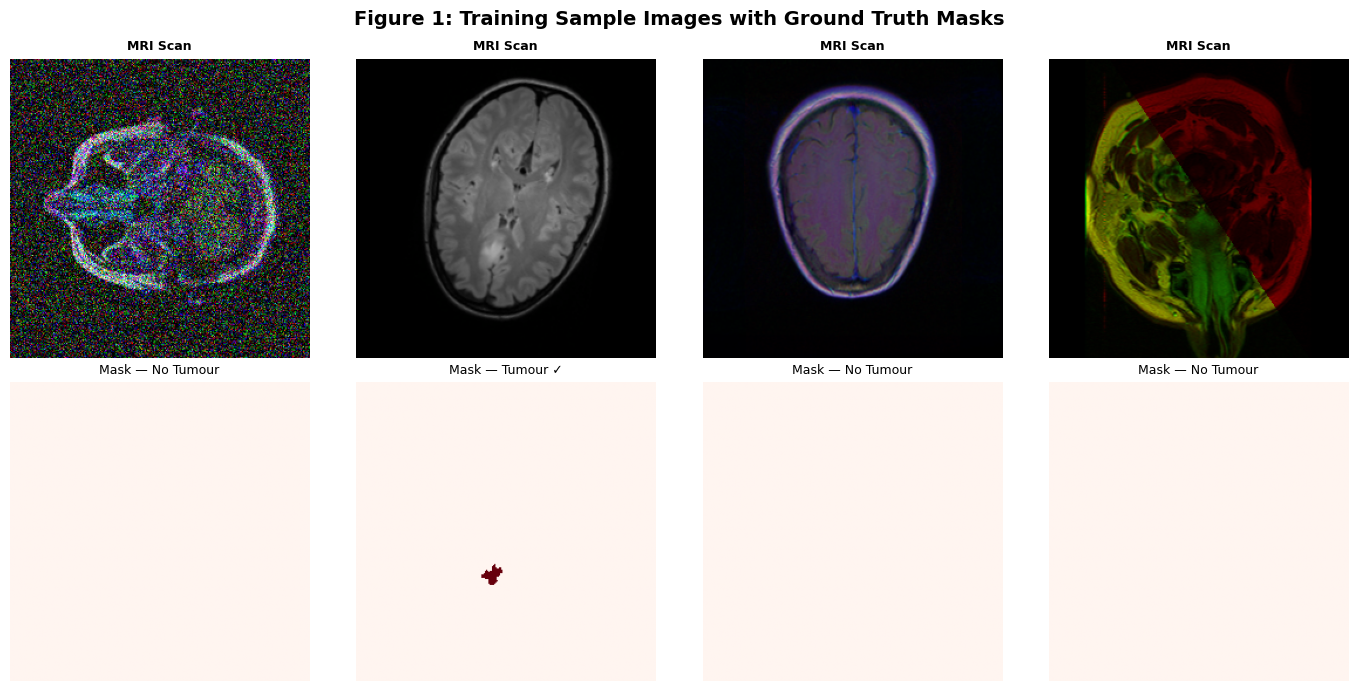

Saved → fig1_samples.png


In [15]:
def show_samples(dataset, n=4, title='Samples', fname='fig1_samples.png'):
    fig, axes = plt.subplots(2, n, figsize=(n * 3.5, 7))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # ImageNet de-normalisation tensors
    mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    indices = random.sample(range(len(dataset)), n)

    for col, i in enumerate(indices):
        img_t, msk_t = dataset[i]

        # Reverse normalisation for display
        img_display = (img_t * std_t + mean_t).permute(1, 2, 0).numpy().clip(0, 1)

        axes[0, col].imshow(img_display)
        axes[0, col].set_title('MRI Scan', fontsize=9, fontweight='bold')
        axes[0, col].axis('off')

        axes[1, col].imshow(msk_t.squeeze(), cmap='Reds')
        has_tumour = 'Tumour ✓' if msk_t.sum() > 0 else 'No Tumour'
        axes[1, col].set_title(f'Mask — {has_tumour}', fontsize=9)
        axes[1, col].axis('off')

    plt.tight_layout()
    plt.savefig(fname, dpi=120)
    plt.show()
    print(f'Saved → {fname}')

show_samples(train_ds,
             title='Figure 1: Training Sample Images with Ground Truth Masks',
             fname='fig1_samples.png')

## Model Architecture

In [16]:
model = smp.Unet(
    encoder_name    = 'resnet34',
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = 1,
    activation      = None,
)

model = model.to(DEVICE)

# Parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
encoder_params   = sum(p.numel() for p in model.encoder.parameters())
decoder_params   = total_params - encoder_params

print('✅ U-Net with ResNet34 encoder created')
print()
print(f'Total parameters    : {total_params:>12,}')
print(f'Trainable params    : {trainable_params:>12,}')
print(f'Encoder params      : {encoder_params:>12,}  (ResNet34)')
print(f'Decoder params      : {decoder_params:>12,}  (U-Net decoder + skip connections)')
print()
print(f'Input  shape : (batch, 3, {IMG_SIZE}, {IMG_SIZE})')
print(f'Output shape : (batch, 1, {IMG_SIZE}, {IMG_SIZE})')

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

✅ U-Net with ResNet34 encoder created

Total parameters    :   24,436,369
Trainable params    :   24,436,369
Encoder params      :   21,284,672  (ResNet34)
Decoder params      :    3,151,697  (U-Net decoder + skip connections)

Input  shape : (batch, 3, 256, 256)
Output shape : (batch, 1, 256, 256)


## Architecture Diagram

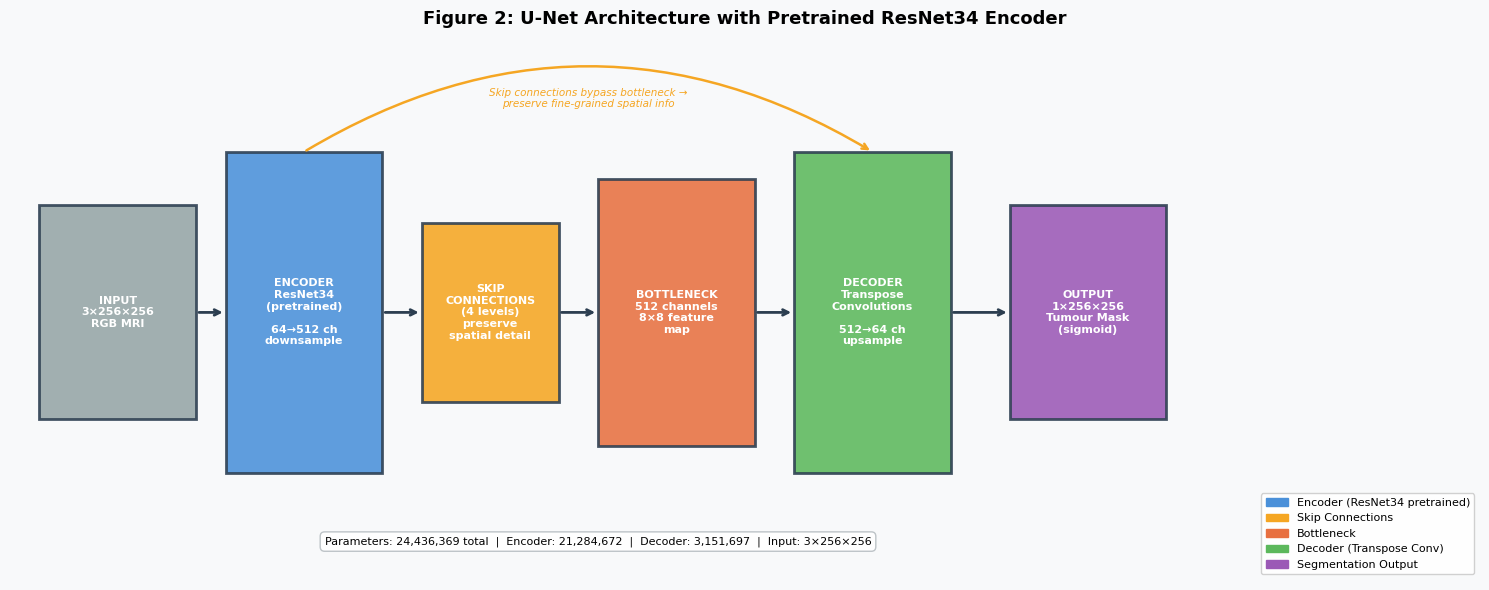

Saved → fig2_architecture.png


In [17]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_xlim(0, 15)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')
ax.set_title('Figure 2: U-Net Architecture with Pretrained ResNet34 Encoder',
             fontsize=13, fontweight='bold', pad=15)

# Colour scheme
C = {'enc': '#4A90D9', 'skip': '#F5A623', 'bot': '#E87040',
     'dec': '#5CB85C', 'out': '#9B59B6'}

# (x, y, width, height, label, colour)
blocks = [
    (0.3, 1.8, 1.6, 2.4, 'INPUT\n3×256×256\nRGB MRI',       '#95A5A6'),
    (2.2, 1.2, 1.6, 3.6, 'ENCODER\nResNet34\n(pretrained)\n\n64→512 ch\ndownsample', C['enc']),
    (4.2, 2.0, 1.4, 2.0, 'SKIP\nCONNECTIONS\n(4 levels)\npreserve\nspatial detail', C['skip']),
    (6.0, 1.5, 1.6, 3.0, 'BOTTLENECK\n512 channels\n8×8 feature\nmap',             C['bot']),
    (8.0, 1.2, 1.6, 3.6, 'DECODER\nTranspose\nConvolutions\n\n512→64 ch\nupsample', C['dec']),
    (10.2,1.8, 1.6, 2.4, 'OUTPUT\n1×256×256\nTumour Mask\n(sigmoid)',              C['out']),
]

for (x, y, w, h, label, col) in blocks:
    rect = plt.Rectangle((x, y), w, h, linewidth=2,
                          edgecolor='#2C3E50', facecolor=col, alpha=0.88,
                          zorder=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=8, fontweight='bold', color='white', zorder=3,
            multialignment='center')

# Arrows
arrow_props = dict(arrowstyle='->', color='#2C3E50', lw=2)
connections = [
    ((1.9, 3.0), (2.2, 3.0)),
    ((3.8, 3.0), (4.2, 3.0)),
    ((5.6, 3.0), (6.0, 3.0)),
    ((7.6, 3.0), (8.0, 3.0)),
    ((9.6, 3.0), (10.2, 3.0)),
]
for (x1, y1), (x2, y2) in connections:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=arrow_props, zorder=4)

# Skip connection arc
ax.annotate('', xy=(8.8, 4.8), xytext=(3.0, 4.8),
            arrowprops=dict(arrowstyle='->', color=C['skip'],
                            lw=1.8, connectionstyle='arc3,rad=-0.3'), zorder=4)
ax.text(5.9, 5.3, 'Skip connections bypass bottleneck →\npreserve fine-grained spatial info',
        ha='center', fontsize=7.5, color=C['skip'], style='italic')

# Stats box
stats = (f'Parameters: {total_params:,} total  |  '
         f'Encoder: {encoder_params:,}  |  '
         f'Decoder: {decoder_params:,}  |  '
         f'Input: 3×{IMG_SIZE}×{IMG_SIZE}')
ax.text(6.0, 0.4, stats, ha='center', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.4', fc='#FEFEFE', ec='#BDC3C7', lw=1))

# Legend
legend_items = [
    mpatches.Patch(color=C['enc'],  label='Encoder (ResNet34 pretrained)'),
    mpatches.Patch(color=C['skip'], label='Skip Connections'),
    mpatches.Patch(color=C['bot'],  label='Bottleneck'),
    mpatches.Patch(color=C['dec'],  label='Decoder (Transpose Conv)'),
    mpatches.Patch(color=C['out'],  label='Segmentation Output'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('fig2_architecture.png', dpi=120)
plt.show()
print('Saved → fig2_architecture.png')

## Loss Function, Optimiser & Scheduler

In [18]:
# ── Loss functions ────────────────────────────────────────────────────────
bce_loss  = nn.BCEWithLogitsLoss()                           # pixel-level
dice_loss = DiceLoss(mode='binary', from_logits=True)        # overlap-based

def combined_loss(pred, target):
    """
    50% BCE + 50% Dice.
    BCE ensures pixel accuracy; Dice handles class imbalance
    by focusing on the overlap ratio.
    """
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

# ── Optimiser ─────────────────────────────────────────────────────────────
optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# ── Learning rate scheduler ───────────────────────────────────────────────
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

# ── Mixed precision scaler ────────────────────────────────────────────────
scaler = GradScaler()

print('✅ Loss, optimiser, scheduler configured')
print(f'Loss       : 0.5 × BCE  +  0.5 × Dice')
print(f'Optimiser  : AdamW  (lr={LR}, weight_decay={WEIGHT_DECAY})')
print(f'Scheduler  : CosineAnnealingLR  (T_max={NUM_EPOCHS}, eta_min=1e-6)')
print(f'Precision  : Mixed (fp16 + fp32)')

✅ Loss, optimiser, scheduler configured
Loss       : 0.5 × BCE  +  0.5 × Dice
Optimiser  : AdamW  (lr=0.0001, weight_decay=1e-05)
Scheduler  : CosineAnnealingLR  (T_max=30, eta_min=1e-6)
Precision  : Mixed (fp16 + fp32)


## Metric Functions


In [19]:
def dice_coefficient(pred_bin, target):
    """
    Dice = 2 * |pred ∩ target| / (|pred| + |target|)
    Ranges 0→1. 1 = perfect overlap.
    pred_bin, target: numpy arrays of 0/1.
    """
    smooth = 1e-6   # avoid division by zero
    inter  = (pred_bin * target).sum()
    return (2.0 * inter + smooth) / (pred_bin.sum() + target.sum() + smooth)


def iou_score(pred_bin, target):
    """
    IoU (Jaccard) = |pred ∩ target| / |pred ∪ target|
    Ranges 0→1. 1 = perfect match.
    """
    smooth = 1e-6
    inter  = (pred_bin * target).sum()
    union  = pred_bin.sum() + target.sum() - inter
    return (inter + smooth) / (union + smooth)


print('✅ Metric functions defined')
print()
print('Testing with dummy predictions:')
perfect = np.ones((10, 10), dtype=np.float32)
print(f'  Perfect prediction  — Dice: {dice_coefficient(perfect, perfect):.4f}  IoU: {iou_score(perfect, perfect):.4f}')
zero = np.zeros((10, 10), dtype=np.float32)
print(f'  All-zero prediction — Dice: {dice_coefficient(zero, perfect):.4f}  IoU: {iou_score(zero, perfect):.4f}')

✅ Metric functions defined

Testing with dummy predictions:
  Perfect prediction  — Dice: 1.0000  IoU: 1.0000
  All-zero prediction — Dice: 0.0000  IoU: 0.0000


## Model Training

In [20]:
history = {
    'train_loss': [],
    'val_loss'  : [],
    'val_dice'  : [],
    'val_iou'   : [],
}
best_val_dice = 0.0

print('=' * 65)
print('  TRAINING — U-Net / ResNet34 / 30 epochs')
print('=' * 65)
print(f'{"Epoch":>6} | {"TrainLoss":>10} | {"ValLoss":>9} | '
      f'{"ValDice":>9} | {"ValIoU":>8} | {"LR":>8}')
print('-' * 65)

for epoch in range(1, NUM_EPOCHS + 1):

    # ══ TRAIN PHASE ══════════════════════════════════════════════════════
    model.train()
    train_loss_sum = 0.0

    for imgs, msks in train_loader:
        imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)

        optimizer.zero_grad()

        with autocast():                    # fp16 forward pass
            preds = model(imgs)
            loss  = combined_loss(preds, msks)

        scaler.scale(loss).backward()       # scaled backward
        scaler.step(optimizer)
        scaler.update()

        train_loss_sum += loss.item() * imgs.size(0)

    train_loss = train_loss_sum / len(train_ds)

    # ══ VALIDATION PHASE ═════════════════════════════════════════════════
    model.eval()
    val_loss_sum = 0.0
    val_dice_sum = 0.0
    val_iou_sum  = 0.0

    with torch.no_grad():
        for imgs, msks in val_loader:
            imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)

            with autocast():
                preds = model(imgs)
                loss  = combined_loss(preds, msks)

            val_loss_sum += loss.item() * imgs.size(0)

            # Binarise predictions at threshold 0.5
            pred_bin = (torch.sigmoid(preds) > 0.5).cpu().numpy().astype(np.uint8)
            msk_np   = msks.cpu().numpy().astype(np.uint8)

            for p, m in zip(pred_bin, msk_np):
                val_dice_sum += dice_coefficient(p, m)
                val_iou_sum  += iou_score(p, m)

    val_loss = val_loss_sum / len(val_ds)
    val_dice = val_dice_sum / len(val_ds)
    val_iou  = val_iou_sum  / len(val_ds)

    # Step scheduler AFTER optimiser
    scheduler.step()
    lr_now = optimizer.param_groups[0]['lr']

    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)

    # Save best model
    tag = ''
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), SAVE_PATH)
        tag = ' ← BEST'

    print(f'{epoch:>6} | {train_loss:>10.4f} | {val_loss:>9.4f} | '
          f'{val_dice:>9.4f} | {val_iou:>8.4f} | {lr_now:>8.2e}{tag}')

print('=' * 65)
print(f'Training complete!  Best Val Dice = {best_val_dice:.4f}')
print(f'Best weights saved → {SAVE_PATH}')

  TRAINING — U-Net / ResNet34 / 30 epochs
 Epoch |  TrainLoss |   ValLoss |   ValDice |   ValIoU |       LR
-----------------------------------------------------------------
     1 |     0.6886 |    0.6156 |    0.7442 |   0.7060 | 9.97e-05 ← BEST
     2 |     0.5724 |    0.5582 |    0.8168 |   0.7748 | 9.89e-05 ← BEST
     3 |     0.5099 |    0.4888 |    0.8542 |   0.8167 | 9.76e-05 ← BEST
     4 |     0.4446 |    0.4095 |    0.8258 |   0.7816 | 9.57e-05
     5 |     0.3543 |    0.3051 |    0.8349 |   0.7996 | 9.34e-05
     6 |     0.2797 |    0.2400 |    0.8833 |   0.8508 | 9.05e-05 ← BEST
     7 |     0.2149 |    0.1757 |    0.8923 |   0.8621 | 8.73e-05 ← BEST
     8 |     0.1809 |    0.1514 |    0.8730 |   0.8405 | 8.36e-05
     9 |     0.1514 |    0.1236 |    0.8836 |   0.8532 | 7.96e-05
    10 |     0.1322 |    0.1154 |    0.8912 |   0.8645 | 7.52e-05
    11 |     0.1302 |    0.1050 |    0.8995 |   0.8707 | 7.06e-05 ← BEST
    12 |     0.1138 |    0.0976 |    0.8861 |   0.8569 | 6

## Plot Training Curves

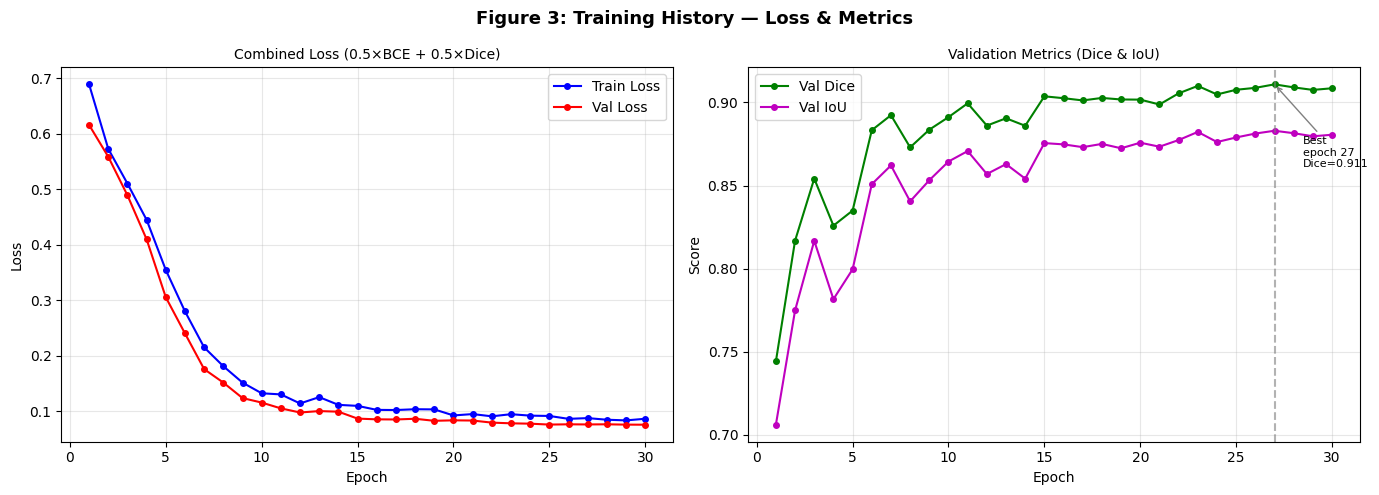

Saved → fig3_training_curves.png


In [21]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 3: Training History — Loss & Metrics',
             fontsize=13, fontweight='bold')

# ── Left: Loss ────────────────────────────────────────────────────────────
axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=4,
             linewidth=1.5, label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   'r-o', markersize=4,
             linewidth=1.5, label='Val Loss')
axes[0].set_title('Combined Loss (0.5×BCE + 0.5×Dice)', fontsize=10)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(0, NUM_EPOCHS + 1, 5))

# ── Right: Metrics ────────────────────────────────────────────────────────
axes[1].plot(epochs, history['val_dice'], 'g-o', markersize=4,
             linewidth=1.5, label='Val Dice')
axes[1].plot(epochs, history['val_iou'],  'm-o', markersize=4,
             linewidth=1.5, label='Val IoU')
axes[1].set_title('Validation Metrics (Dice & IoU)', fontsize=10)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xticks(range(0, NUM_EPOCHS + 1, 5))

# Annotate best epoch
best_ep = np.argmax(history['val_dice']) + 1
best_dc = max(history['val_dice'])
axes[1].axvline(x=best_ep, color='gray', linestyle='--', alpha=0.6)
axes[1].annotate(f'Best\nepoch {best_ep}\nDice={best_dc:.3f}',
                 xy=(best_ep, best_dc),
                 xytext=(best_ep + 1.5, best_dc - 0.05),
                 fontsize=8,
                 arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.savefig('fig3_training_curves.png', dpi=120)
plt.show()
print('Saved → fig3_training_curves.png')

## Model Evaluation

In [22]:
# Load best weights
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()
print(f'✅ Loaded best model from {SAVE_PATH}')
print()

# ── Collect all test predictions ──────────────────────────────────────────
all_preds_flat   = []
all_targets_flat = []
per_dice         = []
per_iou          = []

with torch.no_grad():
    for imgs, msks in test_loader:
        imgs = imgs.to(DEVICE)

        with autocast():
            preds = model(imgs)

        pred_bin = (torch.sigmoid(preds) > 0.5).cpu().numpy().astype(np.uint8)
        msk_np   = msks.numpy().astype(np.uint8)

        # Flatten for pixel-level sklearn metrics
        all_preds_flat.append(pred_bin.flatten())
        all_targets_flat.append(msk_np.flatten())

        # Per-image dice & IoU
        for p, m in zip(pred_bin, msk_np):
            per_dice.append(dice_coefficient(p, m))
            per_iou.append(iou_score(p, m))

all_preds_flat   = np.concatenate(all_preds_flat)
all_targets_flat = np.concatenate(all_targets_flat)

# ── Compute metrics ───────────────────────────────────────────────────────
test_dice      = np.mean(per_dice)
test_dice_std  = np.std(per_dice)
test_iou       = np.mean(per_iou)
test_iou_std   = np.std(per_iou)
precision_val  = precision_score(all_targets_flat, all_preds_flat, zero_division=0)
recall_val     = recall_score(all_targets_flat, all_preds_flat,    zero_division=0)
f1_val         = f1_score(all_targets_flat, all_preds_flat,        zero_division=0)

# ── Print results table ───────────────────────────────────────────────────
print('=' * 50)
print('  TEST SET RESULTS')
print('=' * 50)
print(f'  Dice Coefficient : {test_dice:.4f}  (±{test_dice_std:.4f})')
print(f'  IoU  Score       : {test_iou:.4f}  (±{test_iou_std:.4f})')
print(f'  Precision        : {precision_val:.4f}')
print(f'  Recall           : {recall_val:.4f}')
print(f'  F1   Score       : {f1_val:.4f}')
print('=' * 50)

✅ Loaded best model from best_unet_resnet34.pth

  TEST SET RESULTS
  Dice Coefficient : 0.9199  (±0.1951)
  IoU  Score       : 0.8900  (±0.2170)
  Precision        : 0.8980
  Recall           : 0.9004
  F1   Score       : 0.8992


## Confusion Matrix & Metrics Visualization

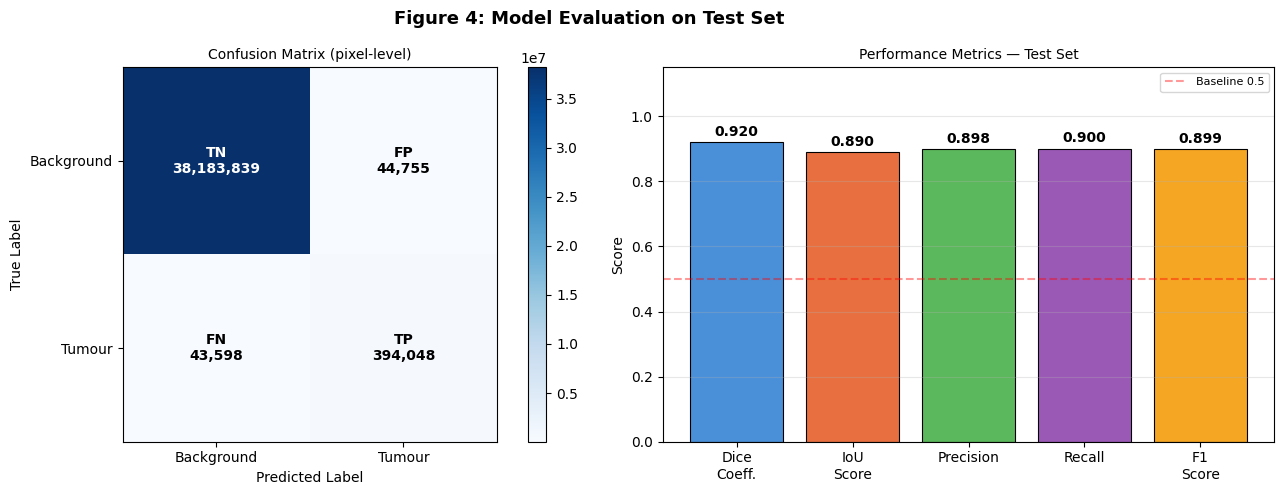

Saved → fig4_confusion_matrix.png

TN=38,183,839  FP=44,755  FN=43,598  TP=394,048


In [23]:
cm = confusion_matrix(all_targets_flat, all_preds_flat)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 4: Model Evaluation on Test Set',
             fontsize=13, fontweight='bold')

# ── Left: Confusion Matrix heatmap ───────────────────────────────────────
im = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('Confusion Matrix (pixel-level)', fontsize=10)
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Background', 'Tumour'])
axes[0].set_yticklabels(['Background', 'Tumour'])
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Annotate cells
labels = [
    [f'TN\n{tn:,}', f'FP\n{fp:,}'],
    [f'FN\n{fn:,}', f'TP\n{tp:,}']
]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, labels[i][j],
                     ha='center', va='center', fontsize=10, fontweight='bold',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')

# ── Right: Metrics bar chart ──────────────────────────────────────────────
metrics = {
    'Dice\nCoeff.': test_dice,
    'IoU\nScore' : test_iou,
    'Precision'  : precision_val,
    'Recall'     : recall_val,
    'F1\nScore'  : f1_val,
}
bar_colors = ['#4A90D9', '#E87040', '#5CB85C', '#9B59B6', '#F5A623']
bars = axes[1].bar(metrics.keys(), metrics.values(),
                   color=bar_colors, edgecolor='black', linewidth=0.8)

for bar, v in zip(bars, metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f'{v:.3f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].set_ylim(0, 1.15)
axes[1].set_title('Performance Metrics — Test Set', fontsize=10)
axes[1].set_ylabel('Score')
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Baseline 0.5')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig4_confusion_matrix.png', dpi=120)
plt.show()
print('Saved → fig4_confusion_matrix.png')
print()
print(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')

## Qualitative Prediction Visualisation

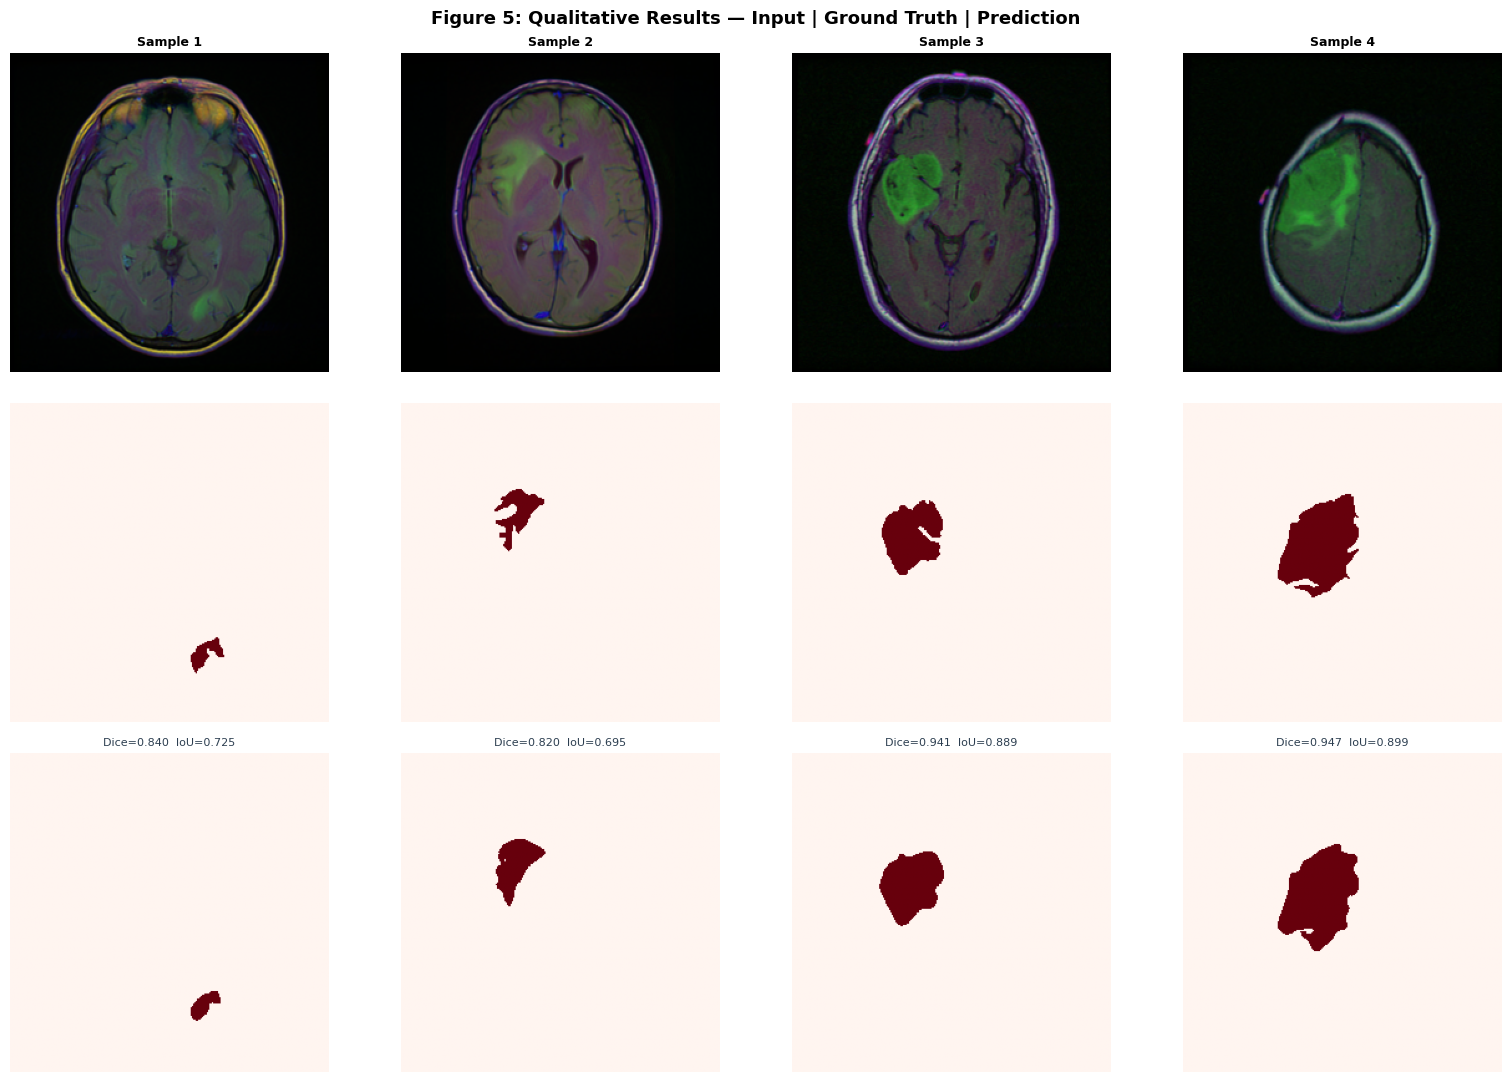

Saved → fig5_predictions.png


In [24]:
model.eval()

# De-normalisation tensors for display
mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# Select samples that have tumours (more visually meaningful)
pos_indices = [i for i in range(len(test_ds))
               if test_ds[i][1].sum() > 100]
if len(pos_indices) < 4:
    pos_indices = random.sample(range(len(test_ds)), 4)
selected = random.sample(pos_indices, min(4, len(pos_indices)))

n = len(selected)
fig, axes = plt.subplots(3, n, figsize=(n * 4, 11))
fig.suptitle('Figure 5: Qualitative Results — Input | Ground Truth | Prediction',
             fontsize=13, fontweight='bold')

row_labels = ['MRI Input', 'Ground Truth\nMask', 'Model\nPrediction']
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=10, fontweight='bold', rotation=90)

for col, idx in enumerate(selected):
    img_t, msk_t = test_ds[idx]

    # De-normalise for display
    img_display = (img_t * std_t + mean_t).permute(1, 2, 0).numpy().clip(0, 1)

    # Run model inference
    with torch.no_grad():
        inp  = img_t.unsqueeze(0).to(DEVICE)
        with autocast():
            out = model(inp)
        pred_prob = torch.sigmoid(out).squeeze().cpu().numpy()
        pred_bin  = (pred_prob > 0.5).astype(np.uint8)

    # Per-image metrics
    d  = dice_coefficient(pred_bin, msk_t.squeeze().numpy())
    io = iou_score(pred_bin, msk_t.squeeze().numpy())

    # Row 0: MRI scan
    axes[0, col].imshow(img_display)
    axes[0, col].set_title(f'Sample {col+1}', fontsize=9, fontweight='bold')
    axes[0, col].axis('off')

    # Row 1: Ground truth
    axes[1, col].imshow(msk_t.squeeze(), cmap='Reds')
    axes[1, col].axis('off')

    # Row 2: Prediction with overlay
    axes[2, col].imshow(pred_bin, cmap='Reds')
    axes[2, col].set_title(f'Dice={d:.3f}  IoU={io:.3f}',
                            fontsize=8, color='#2C3E50')
    axes[2, col].axis('off')

plt.tight_layout()
plt.savefig('fig5_predictions.png', dpi=120)
plt.show()
print('Saved → fig5_predictions.png')

## State-of-the-Art Comparison

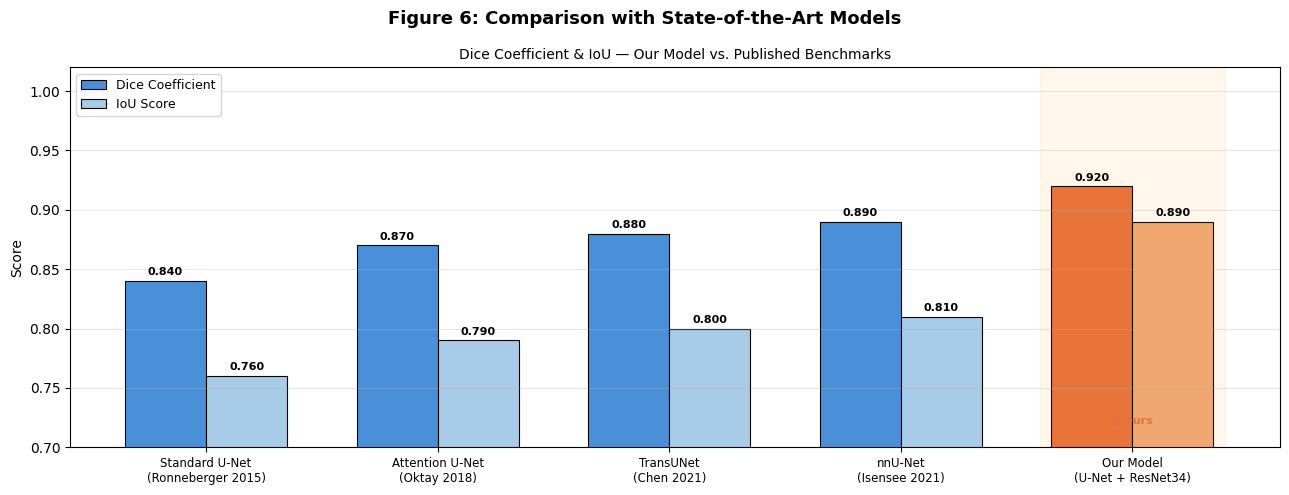

Saved → fig6_sota_comparison.png


In [25]:
# Published benchmarks for brain tumour segmentation
sota_models = {
    'Standard U-Net\n(Ronneberger 2015)' : (0.840, 0.760),
    'Attention U-Net\n(Oktay 2018)'       : (0.870, 0.790),
    'TransUNet\n(Chen 2021)'              : (0.880, 0.800),
    'nnU-Net\n(Isensee 2021)'             : (0.890, 0.810),
    'Our Model\n(U-Net + ResNet34)'       : (test_dice, test_iou),
}

names  = list(sota_models.keys())
dices  = [v[0] for v in sota_models.values()]
ious   = [v[1] for v in sota_models.values()]
x      = np.arange(len(names))
width  = 0.35

# Colours — highlight our model in orange
dice_colors = ['#4A90D9'] * 4 + ['#E87040']
iou_colors  = ['#A8CBE8'] * 4 + ['#F0A87A']

fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('Figure 6: Comparison with State-of-the-Art Models',
             fontsize=13, fontweight='bold')

bars1 = ax.bar(x - width/2, dices, width, label='Dice Coefficient',
               color=dice_colors, edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, ious,  width, label='IoU Score',
               color=iou_colors,  edgecolor='black', linewidth=0.8)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylim(0.70, 1.02)
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=8.5)
ax.set_ylabel('Score')
ax.set_title('Dice Coefficient & IoU — Our Model vs. Published Benchmarks',
             fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Highlight our model column
ax.axvspan(x[-1] - 0.4, x[-1] + 0.4, alpha=0.08, color='orange')
ax.text(x[-1], 0.72, '▲ Ours', ha='center', fontsize=8,
        color='#E87040', fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_sota_comparison.png', dpi=120)
plt.show()
print('Saved → fig6_sota_comparison.png')